# Esercizio 2 - Classificazione con un modello sequenziale

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

dataset = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = dataset.load_data()

print(f"Train images dimensions: {train_images.shape}")
print(f"Test images dimensions: {test_images.shape}")

Train images dimensions: (60000, 28, 28)
Test images dimensions: (10000, 28, 28)


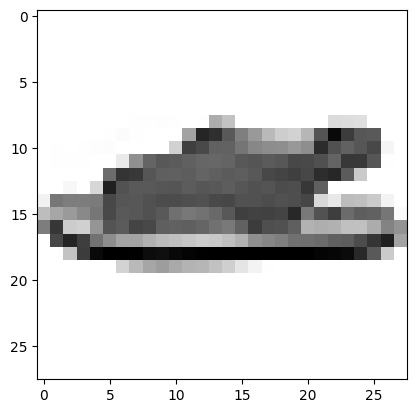

In [3]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


plt.imshow(train_images[np.random.randint(0, 60000)], cmap='gray_r')

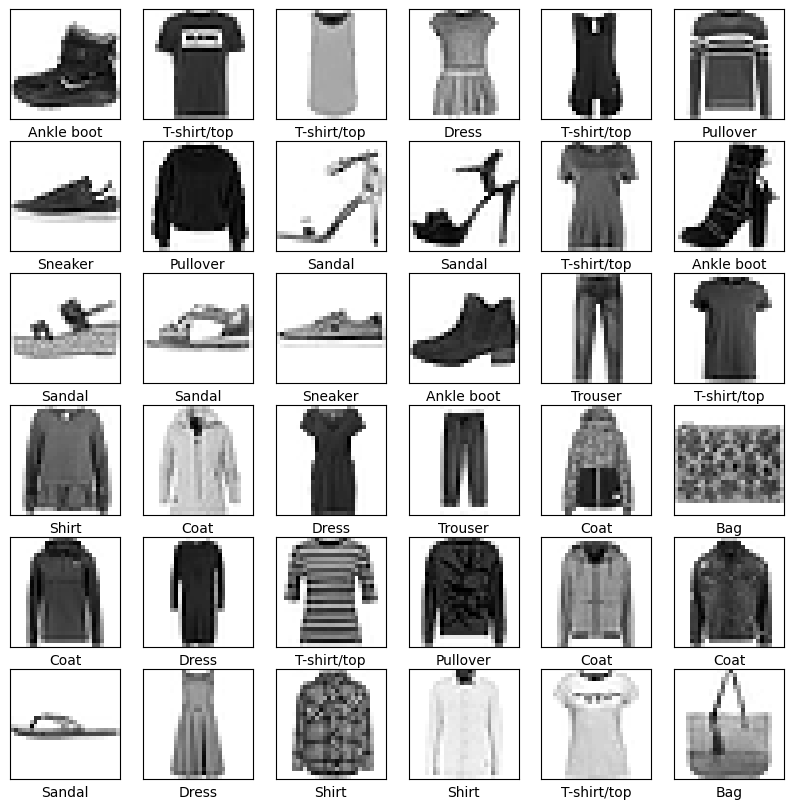

In [4]:
def plot_sample(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(36):
        plt.subplot(6,6,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i], cmap='grey_r')
        plt.xlabel(classes[labels[i]])
    plt.show()

norm = np.max(train_images)
train_images = train_images / norm
test_images = test_images / norm

plot_sample(train_images, train_labels)

Creiamo un modello in keras

In [5]:
%%time
with tf.device('/CPU:0'): 
    tf.debugging.set_log_device_placement(True)
    print(tf.config.list_physical_devices())
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.Dense(len(classes), activation="softmax"))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    epochs = 5
    model.fit(train_images, train_labels, epochs=epochs)

    test_loss, test_acc = model.evaluate(test_images, test_labels)

    print(f"Test set loss: {test_loss}")
    print(f"Test set accuracy: {test_acc}")

    predicts = model.predict(test_images)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-23 20:09:40.072760: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-23 20:09:40.072791: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-23 20:09:40.072798: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-23 20:09:40.072833: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-23 20:09:40.072869: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/francescospecchia/Desktop/UNI/DL/Repo/Lab/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` ar

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8253 - loss: 0.4992
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8650 - loss: 0.3760
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8767 - loss: 0.3385
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8855 - loss: 0.3129
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8920 - loss: 0.2963
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - accuracy: 0.8783 - loss: 0.3427
Test set loss: 0.34267011284828186
Test set accuracy: 0.8783000111579895
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step
CPU times: user 16.5 s, sys: 5.42 s, total: 21.9 s
Wall time: 13.1 s


In [8]:
with tf.device('/GPU:0'):
    model.fit(train_images, train_labels, epochs=epochs)


Epoch 1/5


2026-03-23 20:10:54.450077: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8218 - loss: 0.9312
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8351 - loss: 0.5999
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8382 - loss: 0.5570
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8375 - loss: 0.5503
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8393 - loss: 0.5424


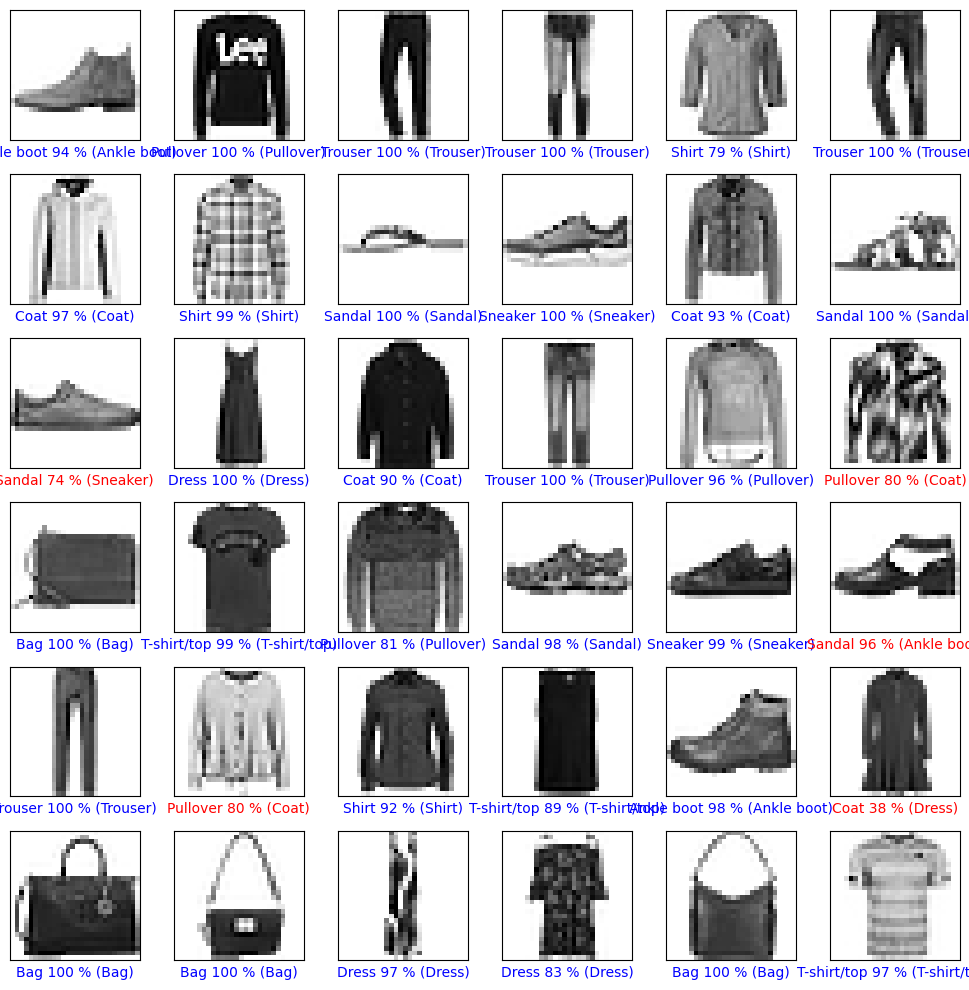

In [6]:
def plot_predictions(predictions, images, labels):

    plt.figure(figsize=(10, 10))
    for i in range(36):
        plt.subplot(6, 6, i + 1)
        plt.imshow(images[i], cmap='grey_r')
        plt.xticks([])
        plt.yticks([])
        predicted_label = np.argmax(predictions[i])
        if predicted_label == labels[i]:
            color = 'blue'
        else:
            color = 'red'
        
        plt.xlabel(f'{classes[predicted_label]} {100*np.max(predictions[i]):2.0f} % ({classes[labels[i]]})', color=color)
    plt.tight_layout()
    plt.show()

plot_predictions(predicts, test_images, test_labels)